# Análisis de Churn de Clientes en Tokio Telecom

## Proyecto de Análisis Big Data

**Autor:** Víctor M. Escudero  
**Empresa:** Tokio Telecom  
**Objetivo del proyecto:**  
Analizar el comportamiento de los clientes de telefonía móvil con el fin de identificar los factores que influyen en la baja del servicio (*churn*), apoyando la toma de decisiones estratégicas orientadas a la retención de clientes.


1 – Inicialización del entorno PySpark

In [1]:
# Instalación de PySpark (solo necesario en Google Colab)
!pip install pyspark
# Creación de la sesión Spark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Tokio Telecom - Customer Churn Analysis") \
    .getOrCreate()


2 – Carga del conjunto de datos

In [3]:
# Carga del fichero CSV en un DataFrame de PySpark
df = spark.read.csv(
    "/content/customer_churn_10k.csv",
    header=True,
    inferSchema=True
)

# Visualización inicial de la estructura
df.printSchema()
df.show(5)


root
 |-- CustomerID: double (nullable = true)
 |-- Age: double (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Tenure: double (nullable = true)
 |-- Usage Frequency: double (nullable = true)
 |-- Support Calls: double (nullable = true)
 |-- Payment Delay: double (nullable = true)
 |-- Subscription Type: string (nullable = true)
 |-- Contract Length: string (nullable = true)
 |-- Total Spend: double (nullable = true)
 |-- Last Interaction: double (nullable = true)
 |-- Churn_YesNo: string (nullable = true)

+----------+----+------+------+---------------+-------------+-------------+-----------------+---------------+-----------+----------------+-----------+
|CustomerID| Age|Gender|Tenure|Usage Frequency|Support Calls|Payment Delay|Subscription Type|Contract Length|Total Spend|Last Interaction|Churn_YesNo|
+----------+----+------+------+---------------+-------------+-------------+-----------------+---------------+-----------+----------------+-----------+
|  314921.0|36.0|  Ma

3 – Normalización de nombres de columnas

In [4]:
# Eliminación de espacios en los nombres de columnas para facilitar su uso
for col in df.columns:
    df = df.withColumnRenamed(col, col.replace(" ", "_"))

df.printSchema()


root
 |-- CustomerID: double (nullable = true)
 |-- Age: double (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Tenure: double (nullable = true)
 |-- Usage_Frequency: double (nullable = true)
 |-- Support_Calls: double (nullable = true)
 |-- Payment_Delay: double (nullable = true)
 |-- Subscription_Type: string (nullable = true)
 |-- Contract_Length: string (nullable = true)
 |-- Total_Spend: double (nullable = true)
 |-- Last_Interaction: double (nullable = true)
 |-- Churn_YesNo: string (nullable = true)



4 – Preparación de la variable objetivo (Churn)

In [5]:
from pyspark.sql import functions as F

# Conversión del indicador de churn a formato numérico
# Yes -> 1 (cliente que abandona)
# No  -> 0 (cliente que permanece)
df = df.withColumn(
    "Churn_Label",
    F.when(F.col("Churn_YesNo") == "Yes", 1).otherwise(0)
)


5 – Análisis por tipo de tarifa


In [6]:
# Cálculo del número de clientes y tasa de churn por tipo de tarifa
df_subscription = df.groupBy("Subscription_Type").agg(
    F.count("*").alias("Total_Customers"),
    F.mean("Churn_Label").alias("Churn_Rate")
)

df_subscription.show()


+-----------------+---------------+------------------+
|Subscription_Type|Total_Customers|        Churn_Rate|
+-----------------+---------------+------------------+
|          Premium|           3406|0.5528479154433353|
|            Basic|           3233|0.5827404887101763|
|         Standard|           3361|0.5667955965486462|
+-----------------+---------------+------------------+



6 – Visualización: churn por tipo de tarifa

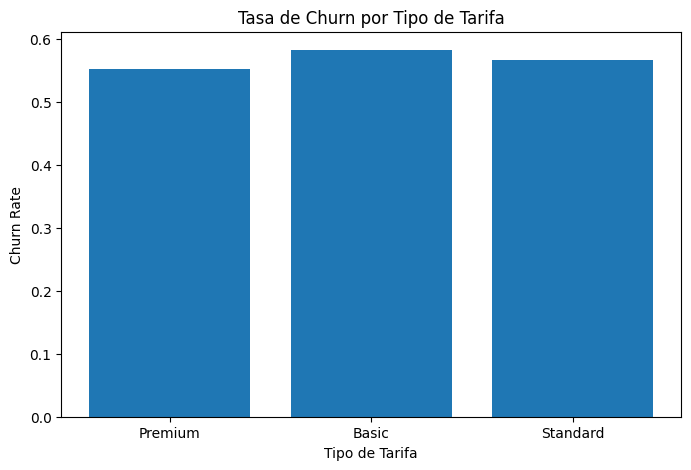

In [7]:
import matplotlib.pyplot as plt

# Conversión a Pandas para visualización
pdf_sub = df_subscription.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf_sub["Subscription_Type"], pdf_sub["Churn_Rate"])
plt.title("Tasa de Churn por Tipo de Tarifa")
plt.xlabel("Tipo de Tarifa")
plt.ylabel("Churn Rate")
plt.show()


7 – Análisis por duración del contrato


In [8]:
# Cálculo del número de clientes y tasa de churn por duración del contrato
df_contract = df.groupBy("Contract_Length").agg(
    F.count("*").alias("Total_Customers"),
    F.mean("Churn_Label").alias("Churn_Rate")
)

df_contract.show()


+---------------+---------------+-------------------+
|Contract_Length|Total_Customers|         Churn_Rate|
+---------------+---------------+-------------------+
|         Annual|           4046| 0.4505684626791893|
|      Quarterly|           3970|0.46977329974811083|
|        Monthly|           1984|                1.0|
+---------------+---------------+-------------------+



8 – Visualización: churn por duración del contrato

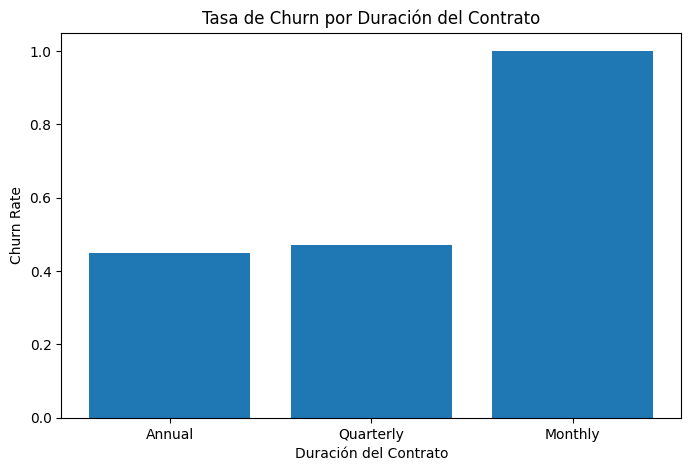

In [9]:
pdf_contract = df_contract.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf_contract["Contract_Length"], pdf_contract["Churn_Rate"])
plt.title("Tasa de Churn por Duración del Contrato")
plt.xlabel("Duración del Contrato")
plt.ylabel("Churn Rate")
plt.show()


9 – Análisis descriptivo de variables numéricas

In [10]:
# Selección de variables numéricas relevantes
numeric_cols = [
    "Age", "Tenure", "Usage_Frequency", "Support_Calls",
    "Payment_Delay", "Total_Spend", "Last_Interaction"
]

# Estadísticos descriptivos básicos
df.select(numeric_cols).describe().show()


+-------+------------------+-----------------+-----------------+------------------+-----------------+------------------+-----------------+
|summary|               Age|           Tenure|  Usage_Frequency|     Support_Calls|    Payment_Delay|       Total_Spend| Last_Interaction|
+-------+------------------+-----------------+-----------------+------------------+-----------------+------------------+-----------------+
|  count|             10000|            10000|            10000|             10000|            10000|             10000|            10000|
|   mean|           39.2613|          30.9536|          15.7726|            3.5932|          13.0305| 633.3173110000018|          14.4916|
| stddev|12.492486883437296|17.13792338300609|8.631357904404563|3.0796529327537288|8.261863929499139|240.47176902802795|8.621076599600162|
|    min|              18.0|              1.0|              1.0|               0.0|              0.0|             100.0|              1.0|
|    max|              65.0

10 – Preparación para análisis de correlación


In [11]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

# Agrupación de variables numéricas en un vector
assembler_corr = VectorAssembler(
    inputCols=numeric_cols,
    outputCol="features_corr"
)

df_corr = assembler_corr.transform(df).select("features_corr")


11 – Matriz de correlación

In [12]:
# Cálculo de la matriz de correlación
corr_matrix = Correlation.corr(df_corr, "features_corr").head()[0]
print(corr_matrix)


DenseMatrix([[ 1.00000000e+00, -6.93105037e-04, -4.41102312e-03,
               1.75940465e-01,  5.38108684e-02, -7.65825742e-02,
               3.31619836e-02],
             [-6.93105037e-04,  1.00000000e+00, -3.17401851e-02,
              -1.86982872e-02,  7.87497227e-03,  1.38211881e-02,
               2.08356376e-03],
             [-4.41102312e-03, -3.17401851e-02,  1.00000000e+00,
              -3.24770925e-02, -3.36540053e-02,  2.98365903e-02,
              -1.03570848e-02],
             [ 1.75940465e-01, -1.86982872e-02, -3.24770925e-02,
               1.00000000e+00,  1.64218631e-01, -2.25403041e-01,
               7.36943183e-02],
             [ 5.38108684e-02,  7.87497227e-03, -3.36540053e-02,
               1.64218631e-01,  1.00000000e+00, -1.22546506e-01,
               4.40346603e-02],
             [-7.65825742e-02,  1.38211881e-02,  2.98365903e-02,
              -2.25403041e-01, -1.22546506e-01,  1.00000000e+00,
              -6.27191846e-02],
             [ 3.31619836e-0

12 – Preparación de variables categóricas

In [13]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

# Variables categóricas a procesar
categorical_cols = ["Gender", "Subscription_Type", "Contract_Length"]

# Indexación de variables categóricas
indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in categorical_cols
]

# Codificación One-Hot
encoder = OneHotEncoder(
    inputCols=[c + "_idx" for c in categorical_cols],
    outputCols=[c + "_vec" for c in categorical_cols]
)


13 – Ensamblado de variables para el modelo

In [14]:
# Variables finales utilizadas por el modelo
feature_cols = numeric_cols + [c + "_vec" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)


14 – Modelo supervisado con validación cruzada

In [17]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Definición del modelo Random Forest
rf = RandomForestClassifier(
    labelCol="Churn_Label",
    featuresCol="features"
)

# Pipeline completo
pipeline = Pipeline(stages=indexers + [encoder, assembler, rf])

# Búsqueda de hiperparámetros
paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [50, 100]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()

# Evaluador del modelo
evaluator = BinaryClassificationEvaluator(
    labelCol="Churn_Label",
    metricName="areaUnderROC"
)

# Validación cruzada
cv = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3
)

# Entrenamiento del modelo
model = cv.fit(train_df)


15 – Resultados del modelo

In [18]:
# Métricas obtenidas para cada combinación de hiperparámetros
print("AUC medio por combinación evaluada:")
print(model.avgMetrics)


AUC medio por combinación evaluada:
[np.float64(0.9938199641636697), np.float64(0.9984123207220746), np.float64(0.9942500231116891), np.float64(0.9991260282139045)]


## Paso 15.1: División de datos en entrenamiento y test

In [16]:

train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count())
print("Test:", test_df.count())


Train: 8079
Test: 1921


## Paso 16: Evaluación del modelo (AUC)

In [19]:

from pyspark.ml.evaluation import BinaryClassificationEvaluator

predictions = model.transform(test_df)

evaluator = BinaryClassificationEvaluator(
    labelCol="Churn_Label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

auc = evaluator.evaluate(predictions)
print("AUC:", auc)


AUC: 0.9994118971117859


## Paso 17: Curva ROC

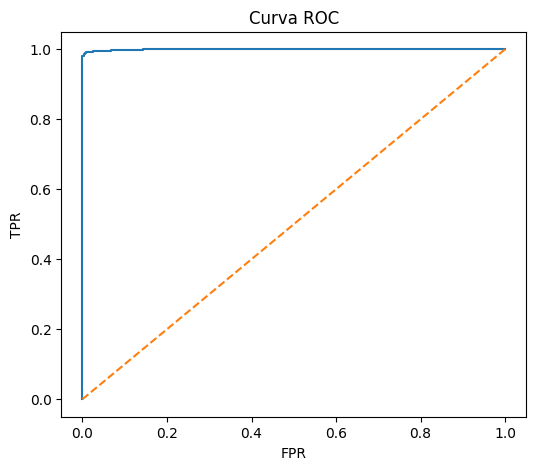

In [20]:

import pandas as pd
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

pred_pd = predictions.select("probability","Churn_Label").toPandas()
pred_pd["prob"] = pred_pd["probability"].apply(lambda x: float(x[1]))

fpr, tpr, _ = roc_curve(pred_pd["Churn_Label"], pred_pd["prob"])

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


## Paso 18: Variables más importantes

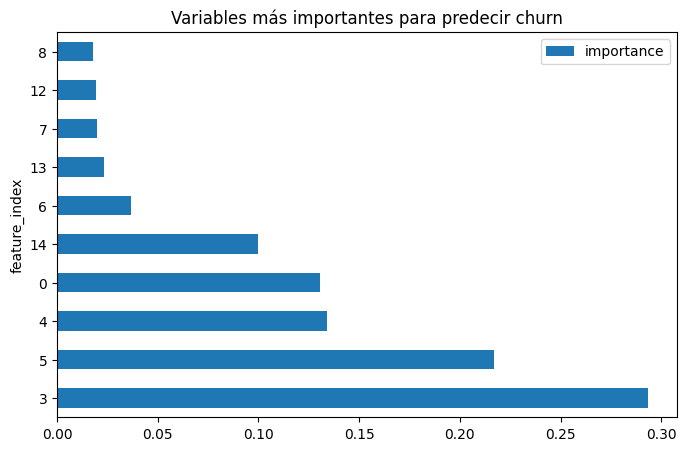

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

rf_model = model.bestModel.stages[-1]

importances = rf_model.featureImportances

# convertir a pandas
df_imp = pd.DataFrame({
    "feature_index": range(len(importances)),
    "importance": list(importances)
}).sort_values("importance", ascending=False).head(10)

df_imp.plot.barh(x="feature_index", y="importance", figsize=(8,5))
plt.title("Variables más importantes para predecir churn")
plt.show()

## Paso 19: Distribución de churn

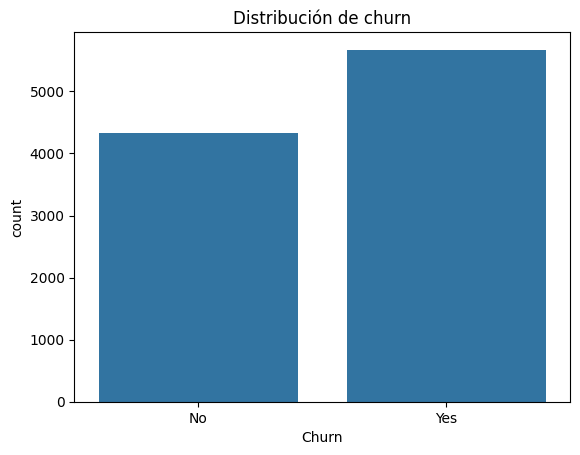

In [33]:
df_pd = df.select("Churn_YesNo").toPandas()

sns.countplot(x="Churn_YesNo", data=df_pd)

plt.title("Distribución de churn")
plt.xlabel("Churn")

plt.show()

## Paso 20: Antigüedad vs churn

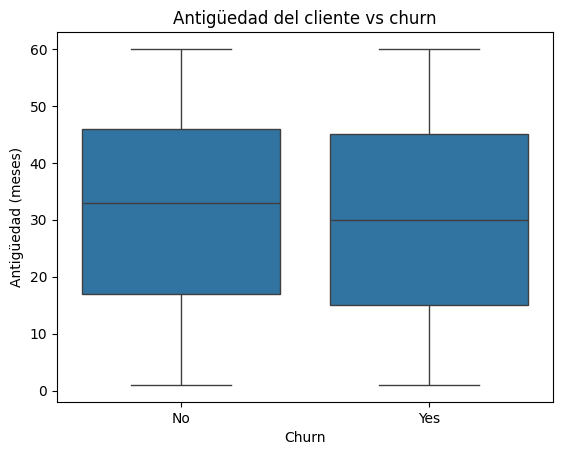

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

df_pd = df.select("Tenure", "Churn_YesNo").toPandas()

sns.boxplot(x="Churn_YesNo", y="Tenure", data=df_pd)

plt.title("Antigüedad del cliente vs churn")
plt.xlabel("Churn")
plt.ylabel("Antigüedad (meses)")

plt.show()

## Paso 21: Churn por contrato

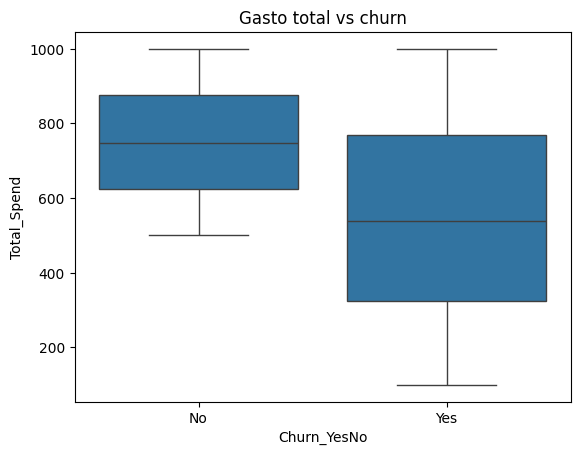

In [34]:
df_pd = df.select("Total_Spend", "Churn_YesNo").toPandas()

sns.boxplot(x="Churn_YesNo", y="Total_Spend", data=df_pd)

plt.title("Gasto total vs churn")

plt.show()

## Paso 22: Coste mensual vs churn

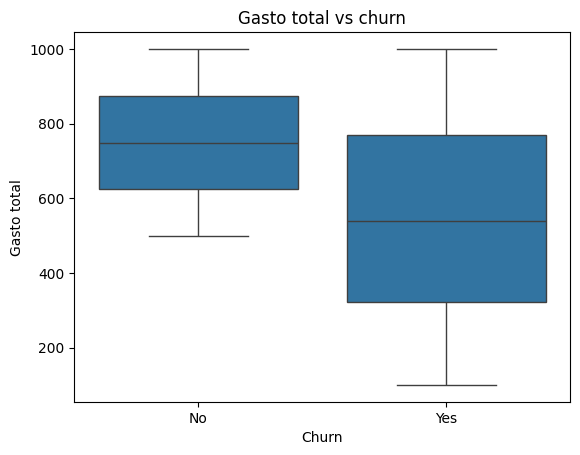

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convertir solo las columnas necesarias a pandas
df_pd = df.select("Total_Spend", "Churn_YesNo").toPandas()

sns.boxplot(x="Churn_YesNo", y="Total_Spend", data=df_pd)

plt.title("Gasto total vs churn")
plt.xlabel("Churn")
plt.ylabel("Gasto total")

plt.show()

## Paso 23: Interpretación


Clientes con menor antigüedad y contratos mensuales presentan mayor probabilidad de churn.
El coste mensual también influye en la decisión de abandono.


## Paso 24: Posibles causas


- Falta de fidelización inicial
- Contratos flexibles
- Costes elevados


## Paso 25: Recomendaciones


- Programas de fidelización
- Descuentos personalizados
- Modelos predictivos para detectar churn


## Paso 26: Impacto en el negocio


Reducir churn mejora ingresos y reduce costes de adquisición.


## Paso 27: Conclusión


El modelo permite identificar clientes en riesgo y tomar decisiones de retención.


## Análisis visual adicional del churn

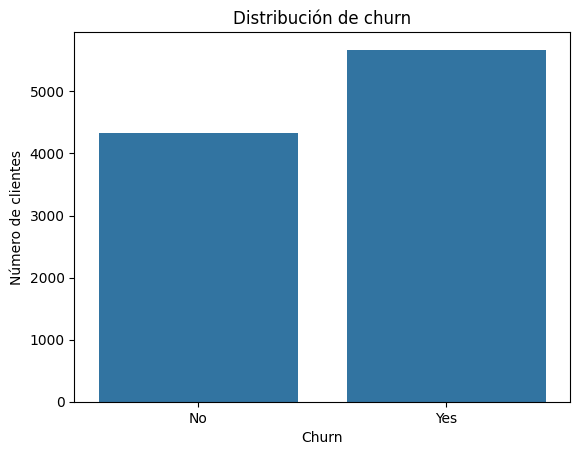

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# convertir solo la columna necesaria a pandas
df_pd = df.select("Churn_YesNo").toPandas()

sns.countplot(x="Churn_YesNo", data=df_pd)

plt.title("Distribución de churn")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")

plt.show()

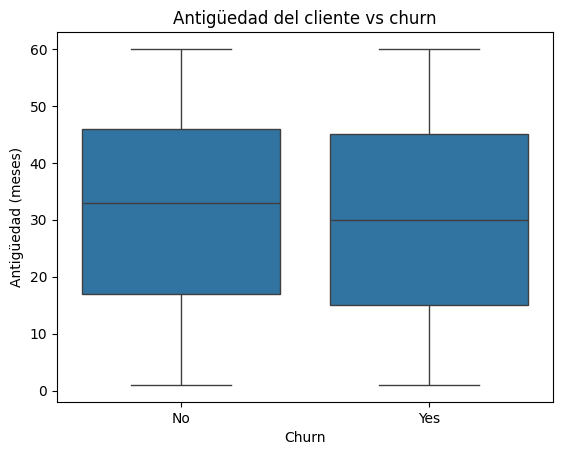

In [39]:

import seaborn as sns
import matplotlib.pyplot as plt

df_pd = df.select("Tenure", "Churn_YesNo").toPandas()

sns.boxplot(x="Churn_YesNo", y="Tenure", data=df_pd)

plt.title("Antigüedad del cliente vs churn")
plt.xlabel("Churn")
plt.ylabel("Antigüedad (meses)")

plt.show()

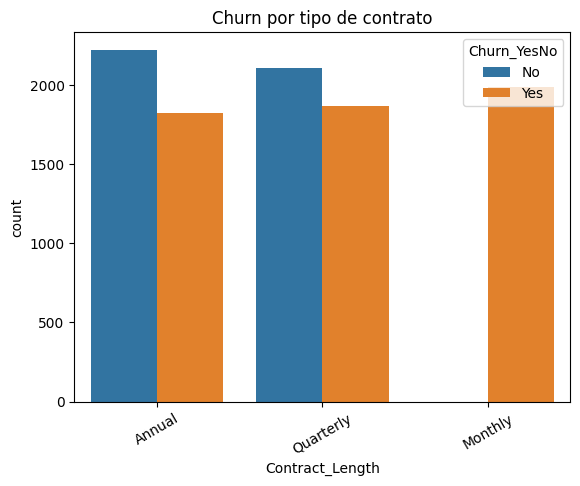

In [40]:

df_pd = df.select("Contract_Length", "Churn_YesNo").toPandas()

sns.countplot(x="Contract_Length", hue="Churn_YesNo", data=df_pd)

plt.title("Churn por tipo de contrato")
plt.xticks(rotation=30)

plt.show()

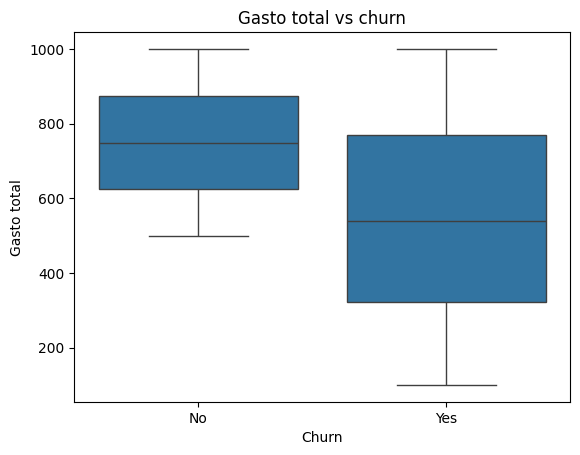

In [41]:

df_pd = df.select("Total_Spend", "Churn_YesNo").toPandas()

sns.boxplot(x="Churn_YesNo", y="Total_Spend", data=df_pd)

plt.title("Gasto total vs churn")
plt.xlabel("Churn")
plt.ylabel("Gasto total")

plt.show()


## Conclusiones de negocio

Los clientes con menor antigüedad y contratos mensuales presentan mayor probabilidad de churn.
El coste mensual también influye en la decisión de abandono.

Estrategias recomendadas:

- Programas de fidelización temprana
- Descuentos personalizados
- Uso del modelo predictivo para campañas de retención
